In [ ]:
# Import required libraries
import sys
import os
sys.path.append('..')  # Add parent directory to path to import our modules

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries imported successfully
PyTorch version: 2.7.1+cu126
NumPy version: 2.2.3
Pandas version: 2.2.3


In [21]:
# Load your pretrained model and scaler
# Update these paths to point to your actual trained model files
MODEL_PATH = "/home/vpalacio/Documents/data/polyprint/PProDOT_Samples/supervised_analysis/RandomForest_model.joblib"
SCALER_PATH = "/home/vpalacio/Documents/data/polyprint/PProDOT_Samples/supervised_analysis/feature_scaler.joblib"

print(f"Model path: {MODEL_PATH}")
print(f"Scaler path: {SCALER_PATH}")


Model path: /home/vpalacio/Documents/data/polyprint/PProDOT_Samples/supervised_analysis/RandomForest_model.joblib
Scaler path: /home/vpalacio/Documents/data/polyprint/PProDOT_Samples/supervised_analysis/feature_scaler.joblib


In [22]:
# Load the pretrained model and scaler
print("Loading pretrained model and scaler...")

try:
    # Load the trained logistic regression model
    model = joblib.load(MODEL_PATH)
    print(f"Model loaded successfully: {type(model).__name__}")
    
    # Load the trained scaler
    scaler = joblib.load(SCALER_PATH)
    print(f"Scaler loaded successfully: {type(scaler).__name__}")
    
    # Display model information
    print(f"\nModel Information:")
    print(f"  Model type: {type(model).__name__}")
    print(f"  Number of features: {model.coef_.shape[1]}")
    print(f"  Model intercept: {model.intercept_[0]:.4f}")
    print(f"  Scaler mean: {scaler.mean_[:5]}...")  # Show first 5 values
    print(f"  Scaler scale: {scaler.scale_[:5]}...")  # Show first 5 values
    
except FileNotFoundError as e:
    print(f"Error: Could not find file - {e}")
    print("Please check the file paths and try again.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure the files are valid joblib/pickle files.")


Loading pretrained model and scaler...
Model loaded successfully: RandomForestClassifier
Scaler loaded successfully: StandardScaler

Model Information:
  Model type: RandomForestClassifier
Error loading model: 'RandomForestClassifier' object has no attribute 'coef_'
Please ensure the files are valid joblib/pickle files.


In [23]:
# Import the model objective factory
from model_objective_factory import create_objective_from_model

# Create the objective function from your pretrained model
print("Creating objective function from pretrained model...")

objective_function = create_objective_from_model(model, scaler)
print("Objective function created successfully")

# Test the objective function with a sample input
print("\nTesting objective function with sample parameters...")
test_params = torch.tensor([
    [0.6, 45.0, 0.2, 15.0],  # Moderate values
    [0.3, 80.0, 0.1, 20.0],  # Different combination
], dtype=torch.float32)

print(f"Test input shape: {test_params.shape}")
print(f"Test parameters:")
print(f"  Sample 1: concentration={test_params[0,0]:.1f}, print_speed={test_params[0,1]:.1f}, gap_size={test_params[0,2]:.1f}, volume={test_params[0,3]:.1f}")
print(f"  Sample 2: concentration={test_params[1,0]:.1f}, print_speed={test_params[1,1]:.1f}, gap_size={test_params[1,2]:.1f}, volume={test_params[1,3]:.1f}")

# Call the objective function
test_results = objective_function(test_params)
print(f"\nTest results shape: {test_results.shape}")
print(f"Success probabilities:")
print(f"  Sample 1: {test_results[0,0]:.4f}")
print(f"  Sample 2: {test_results[1,0]:.4f}")

print("\nObjective function is working correctly")


Creating objective function from pretrained model...
Model expects 18 features
Objective function created successfully

Testing objective function with sample parameters...
Test input shape: torch.Size([2, 4])
Test parameters:
  Sample 1: concentration=0.6, print_speed=45.0, gap_size=0.2, volume=15.0
  Sample 2: concentration=0.3, print_speed=80.0, gap_size=0.1, volume=20.0

Test results shape: torch.Size([2, 1])
Success probabilities:
  Sample 1: 0.8181
  Sample 2: 0.8181

Objective function is working correctly


In [24]:
# Import the Bayesian optimizer
from bayesian_optimizer import BayesianOptimizer

# Define parameter bounds based on typical polymer printing ranges
bounds = torch.tensor([
    [20.0, 0.0, 50, 4.0],    # Lower bounds: [concentration, print_speed, gap_size, volume]
    [100.0, 20.0, 200, 15.0]   # Upper bounds: [concentration, print_speed, gap_size, volume]
], dtype=torch.float64)

print("Parameter bounds:")
print(f"  Concentration: [{bounds[0,0]:.1f}, {bounds[1,0]:.1f}] mg/mL")
print(f"  Print Speed: [{bounds[0,1]:.1f}, {bounds[1,1]:.1f}] mm/s")
print(f"  Gap Size: [{bounds[0,2]:.3f}, {bounds[1,2]:.3f}] mm")
print(f"  Volume: [{bounds[0,3]:.1f}, {bounds[1,3]:.1f}] μL")

# Initialize the Bayesian optimizer
optimizer = BayesianOptimizer(
    bounds=bounds,
    batch_size=6,  # Evaluate 6 candidates per iteration
    seed=42
)

print(f"\nBayesian optimizer initialized with:")
print(f"  Batch size: {optimizer.batch_size}")
print(f"  Parameter dimensions: {optimizer.n_dims}")
print(f"  Seed: {optimizer.seed}")


Parameter bounds:
  Concentration: [20.0, 100.0] mg/mL
  Print Speed: [0.0, 20.0] mm/s
  Gap Size: [50.000, 200.000] mm
  Volume: [4.0, 15.0] μL

Bayesian optimizer initialized with:
  Batch size: 6
  Parameter dimensions: 4
  Seed: 42


In [25]:
# Run Bayesian optimization
print("Starting Bayesian optimization...")
print("This will find the optimal printing parameters to maximize success probability.")
print("=" * 60)

# Run the optimization
best_params, best_score = optimizer.optimize(
    objective_function=objective_function,
    n_iterations=12,  # Number of optimization iterations
    n_initial_points=8,  # Number of initial random points
    verbose=True
)

print("=" * 60)
print("Optimization completed")
print(f"Best success probability: {best_score:.4f}")
print(f"Best parameters:")
print(f"  Concentration: {best_params[0]:.3f} mg/mL")
print(f"  Print Speed: {best_params[1]:.1f} mm/s")
print(f"  Gap Size: {best_params[2]:.3f} mm")
print(f"  Volume: {best_params[3]:.1f} μL")


Starting Bayesian optimization...
This will find the optimal printing parameters to maximize success probability.
BAYESIAN OPTIMIZATION STARTING
Parameters: 4 dimensions
Batch size: 6
Iterations: 12
Initial points: 8
Generating 8 initial training points...
Initial best score: 0.9881
Initial best parameters: tensor([ 27.0488,  14.0236, 143.5105,   8.8101], dtype=torch.float64)

Iteration 1/12
----------------------------------------
Fitting GP model...
Optimizing acquisition function...
Evaluating 6 candidates...
Current best score: 0.9881
Current best parameters: tensor([ 27.0488,  14.0236, 143.5105,   8.8101], dtype=torch.float64)

Iteration 2/12
----------------------------------------
Fitting GP model...
Optimizing acquisition function...
Evaluating 6 candidates...
Current best score: 0.9886
Current best parameters: tensor([ 20.0000,  16.0668, 123.0113,   9.5847])

Iteration 3/12
----------------------------------------
Fitting GP model...
Optimizing acquisition function...
Evaluati

In [26]:
# Get all evaluated points during optimization
train_X, train_Y = optimizer.get_training_data()

print(f"Optimization Summary:")
print(f"  Total evaluations: {len(train_Y)}")
print(f"  Best score: {train_Y.max().item():.4f}")
print(f"  Worst score: {train_Y.min().item():.4f}")
print(f"  Mean score: {train_Y.mean().item():.4f}")
print(f"  Score improvement: {(train_Y.max() - train_Y.min()).item():.4f}")

# Find top 5 parameter combinations
print(f"\\nTop 5 parameter combinations:")
sorted_indices = torch.argsort(train_Y.flatten(), descending=True)
for i, idx in enumerate(sorted_indices[:5]):
    params = train_X[idx]
    score = train_Y[idx].item()
    print(f"  {i+1}. Score: {score:.4f} | "
          f"Conc: {params[0]:.3f}, Speed: {params[1]:.1f}, "
          f"Gap: {params[2]:.3f}, Vol: {params[3]:.1f}")

# Convert to numpy for plotting
eval_params = train_X.cpu().numpy()
eval_scores = train_Y.cpu().numpy().flatten()

print(f"\\nCreating visualizations...")


Optimization Summary:
  Total evaluations: 80
  Best score: 0.9897
  Worst score: 0.3873
  Mean score: 0.9386
  Score improvement: 0.6024
\nTop 5 parameter combinations:
  1. Score: 0.9897 | Conc: 20.000, Speed: 8.2, Gap: 126.225, Vol: 10.2
  2. Score: 0.9888 | Conc: 20.000, Speed: 5.9, Gap: 145.855, Vol: 9.2
  3. Score: 0.9886 | Conc: 20.000, Speed: 19.1, Gap: 121.952, Vol: 8.5
  4. Score: 0.9886 | Conc: 20.000, Speed: 16.1, Gap: 123.011, Vol: 9.6
  5. Score: 0.9883 | Conc: 24.166, Speed: 20.0, Gap: 130.074, Vol: 6.4
\nCreating visualizations...


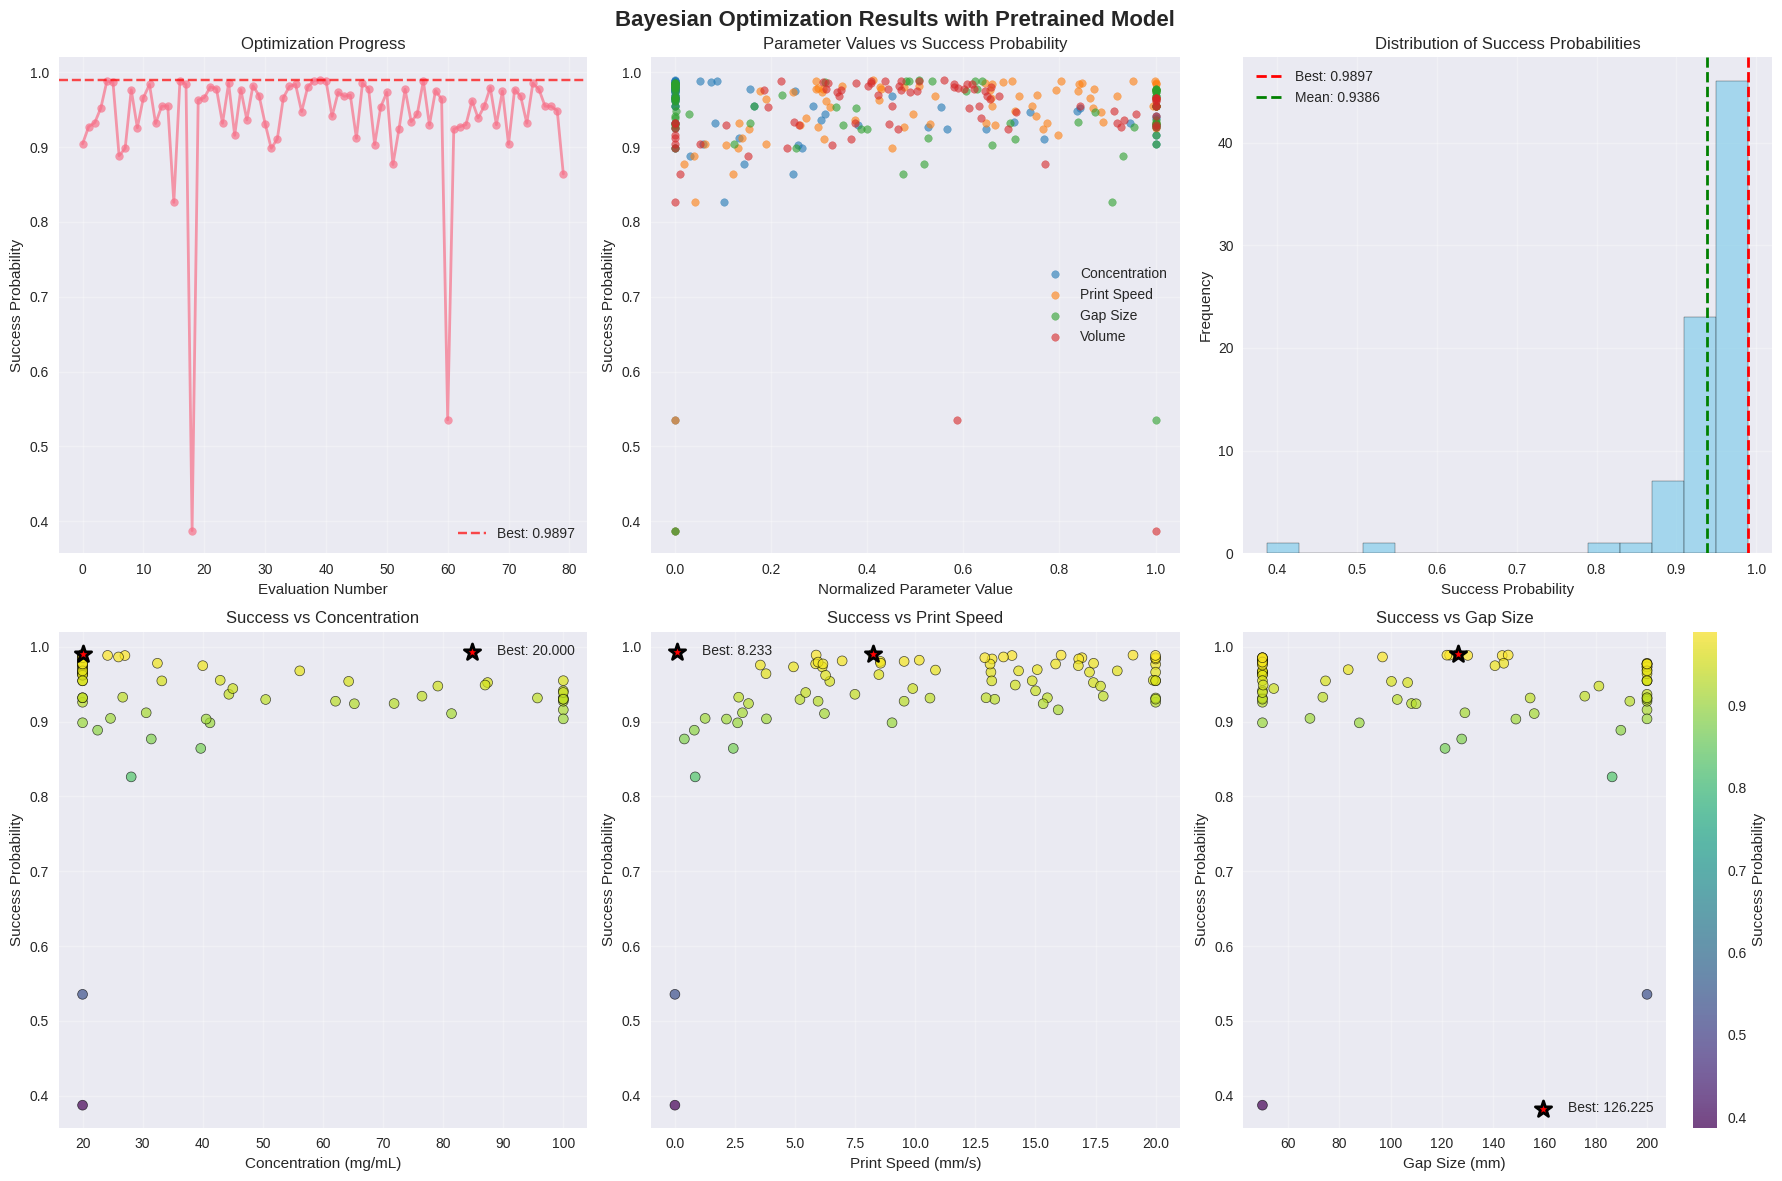

Visualizations created successfully


In [27]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Bayesian Optimization Results with Pretrained Model', fontsize=16, fontweight='bold')

# 1. Optimization progress
ax1 = axes[0, 0]
ax1.plot(range(len(eval_scores)), eval_scores, 'o-', alpha=0.7, linewidth=2, markersize=6)
ax1.set_xlabel('Evaluation Number')
ax1.set_ylabel('Success Probability')
ax1.set_title('Optimization Progress')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=best_score, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_score:.4f}')
ax1.legend()

# 2. Parameter distributions
param_names = ['Concentration', 'Print Speed', 'Gap Size', 'Volume']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

ax2 = axes[0, 1]
for i, (param_name, color) in enumerate(zip(param_names, colors)):
    # Normalize parameters to [0,1] for comparison
    param_values = eval_params[:, i]
    param_min = bounds[0, i].item()
    param_max = bounds[1, i].item()
    normalized_values = (param_values - param_min) / (param_max - param_min)
    
    ax2.scatter(normalized_values, eval_scores, alpha=0.6, label=param_name, 
               color=color, s=30)

ax2.set_xlabel('Normalized Parameter Value')
ax2.set_ylabel('Success Probability')
ax2.set_title('Parameter Values vs Success Probability')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Score distribution
ax3 = axes[0, 2]
ax3.hist(eval_scores, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
ax3.axvline(x=best_score, color='red', linestyle='--', linewidth=2, label=f'Best: {best_score:.4f}')
ax3.axvline(x=np.mean(eval_scores), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(eval_scores):.4f}')
ax3.set_xlabel('Success Probability')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Success Probabilities')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4-6. Individual parameter analysis
for i, param_name in enumerate(param_names[:3]):
    ax = axes[1, i]
    
    # Create scatter plot
    param_values = eval_params[:, i]
    scatter = ax.scatter(param_values, eval_scores, c=eval_scores, cmap='viridis', 
                       alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    
    # Highlight best point
    best_idx = np.argmax(eval_scores)
    ax.scatter(param_values[best_idx], eval_scores[best_idx], 
              color='red', s=150, marker='*', edgecolors='black', linewidth=2,
              label=f'Best: {param_values[best_idx]:.3f}')
    
    # Get units for each parameter
    units = ['mg/mL', 'mm/s', 'mm', 'μL']
    ax.set_xlabel(f'{param_name} ({units[i]})')
    ax.set_ylabel('Success Probability')
    ax.set_title(f'Success vs {param_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add colorbar to the last subplot
    if i == 2:
        plt.colorbar(scatter, ax=ax, label='Success Probability')

plt.tight_layout()
plt.show()

print("Visualizations created successfully")


Performing parameter sensitivity analysis...
Analyzing sensitivity for Concentration...
  Range tested: [20.000, 36.000]
  Score range: [0.9789, 0.9897]
  Sensitivity: 0.000677 (score change per unit parameter change)
Analyzing sensitivity for Print Speed...
  Range tested: [4.233, 12.233]
  Score range: [0.9645, 0.9897]
  Sensitivity: 0.003155 (score change per unit parameter change)
Analyzing sensitivity for Gap Size...
  Range tested: [96.225, 156.225]
  Score range: [0.9688, 0.9906]
  Sensitivity: 0.000363 (score change per unit parameter change)
Analyzing sensitivity for Volume...
  Range tested: [7.965, 12.365]
  Score range: [0.9754, 0.9897]
  Sensitivity: 0.003243 (score change per unit parameter change)


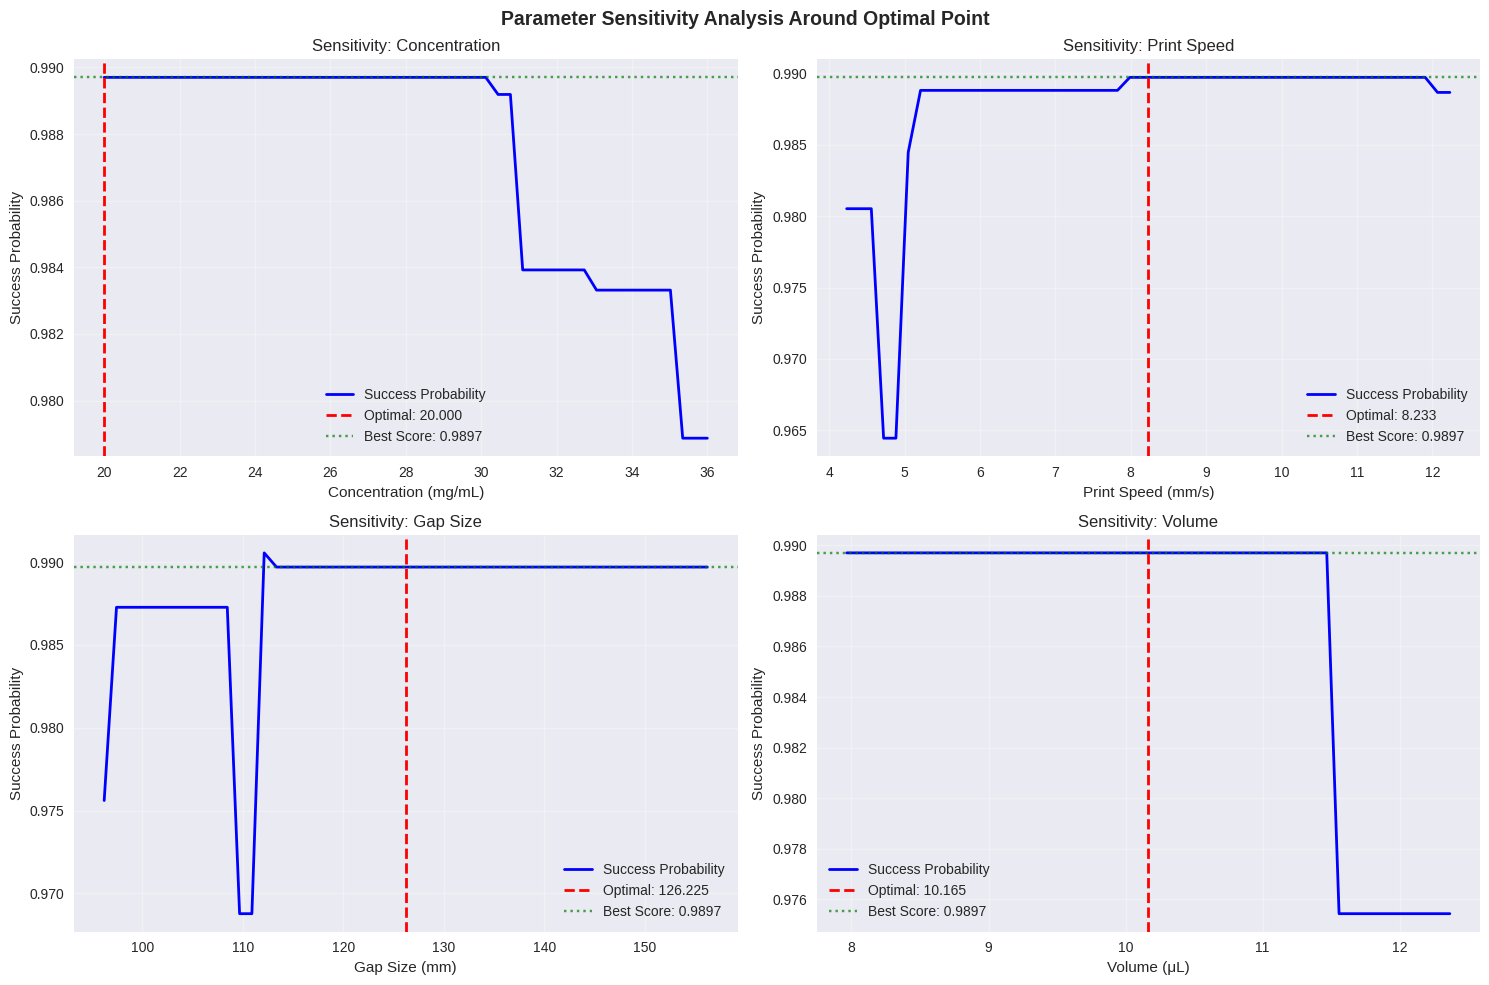

Sensitivity analysis completed


In [28]:
# Parameter sensitivity analysis around the optimal point
print("Performing parameter sensitivity analysis...")

# Create parameter variations around the optimal point
n_points = 50
sensitivity_results = {}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Parameter Sensitivity Analysis Around Optimal Point', fontsize=14, fontweight='bold')

for param_idx, param_name in enumerate(param_names):
    print(f"Analyzing sensitivity for {param_name}...")
    
    # Create range around optimal value
    optimal_value = best_params[param_idx].item()
    param_min = bounds[0, param_idx].item()
    param_max = bounds[1, param_idx].item()
    
    # Create range ±20% around optimal value, bounded by parameter limits
    range_width = (param_max - param_min) * 0.2
    test_min = max(param_min, optimal_value - range_width)
    test_max = min(param_max, optimal_value + range_width)
    test_values = np.linspace(test_min, test_max, n_points)
    
    # Create test parameters (fix other parameters at optimal values)
    test_params_list = []
    for test_val in test_values:
        test_param = best_params.clone()
        test_param[param_idx] = test_val
        test_params_list.append(test_param)
    
    # Stack into batch tensor
    test_batch = torch.stack(test_params_list).float()
    
    # Evaluate objective function
    with torch.no_grad():
        test_scores = objective_function(test_batch).cpu().numpy().flatten()
    
    # Store results
    sensitivity_results[param_name] = {
        'values': test_values,
        'scores': test_scores,
        'optimal_value': optimal_value,
        'optimal_score': best_score
    }
    
    # Plot results
    ax = axes[param_idx // 2, param_idx % 2]
    ax.plot(test_values, test_scores, 'b-', linewidth=2, label='Success Probability')
    ax.axvline(x=optimal_value, color='red', linestyle='--', linewidth=2, 
               label=f'Optimal: {optimal_value:.3f}')
    ax.axhline(y=best_score, color='green', linestyle=':', alpha=0.7, 
               label=f'Best Score: {best_score:.4f}')
    
    units = ['mg/mL', 'mm/s', 'mm', 'μL']
    ax.set_xlabel(f'{param_name} ({units[param_idx]})')
    ax.set_ylabel('Success Probability')
    ax.set_title(f'Sensitivity: {param_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Calculate sensitivity metrics
    score_range = test_scores.max() - test_scores.min()
    param_range = test_max - test_min
    sensitivity = score_range / param_range if param_range > 0 else 0
    
    print(f"  Range tested: [{test_min:.3f}, {test_max:.3f}]")
    print(f"  Score range: [{test_scores.min():.4f}, {test_scores.max():.4f}]")
    print(f"  Sensitivity: {sensitivity:.6f} (score change per unit parameter change)")

plt.tight_layout()
plt.show()

print("Sensitivity analysis completed")
